## Compare all models
Compare the constraining power of different volumes of data on the model parameters.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


CUDA is not available. Using CPU.


## Load a model

In [ ]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
names = cosmonames  # +hodnames

# # Specify model configuration
# nbody = 'mtnglike'
# sim = 'fastpm_hodzbias'
# save_dir = join(wdir, nbody, sim, 'models')

# Specify data dtype
# tracer = 'halo'
tracer = 'galaxy'
summaries = ['nbar', 'zPk0', 'zPk2', 'zPk4']  # ,  'zQk0']
# summaries = ['Pk0', 'Pk2', 'Pk4', 'Qk0']
summary = '+'.join(summaries)
kmin, kmax = 0.0, 0.4
# modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')
# print(
#     f'Loading model: nbody={nbody}, sim={sim}, tracer={tracer}, \n\tsummary={summary}, kmin={kmin}, kmax={kmax}')
# print('\n'.join(os.listdir(modelpath)))

In [89]:
suites = ['quijotelike', 'abacuslike', 'mtnglike']
vols = (np.array([1, 2, 3]))**3

xtests, ytests, sampss, percss = [], [], [], []
for i, s in enumerate(suites):
    # Specify model configuration
    nbody = s
    sim = 'fastpm' if s == 'quijotelike' else 'fastpm_hodzbias'
    save_dir = join(wdir, nbody, sim, 'models')
    modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

    # Load predictions
    xtest = np.load(join(modelpath, 'x_test.npy'))
    ytest = np.load(join(modelpath, 'theta_test.npy'))
    samps = np.load(join(modelpath, 'posterior_samples.npy'))
    percs = np.percentile(samps, [16, 50, 84], axis=0)
    xtests.append(xtest), ytests.append(ytest)
    sampss.append(samps), percss.append(percs)

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)

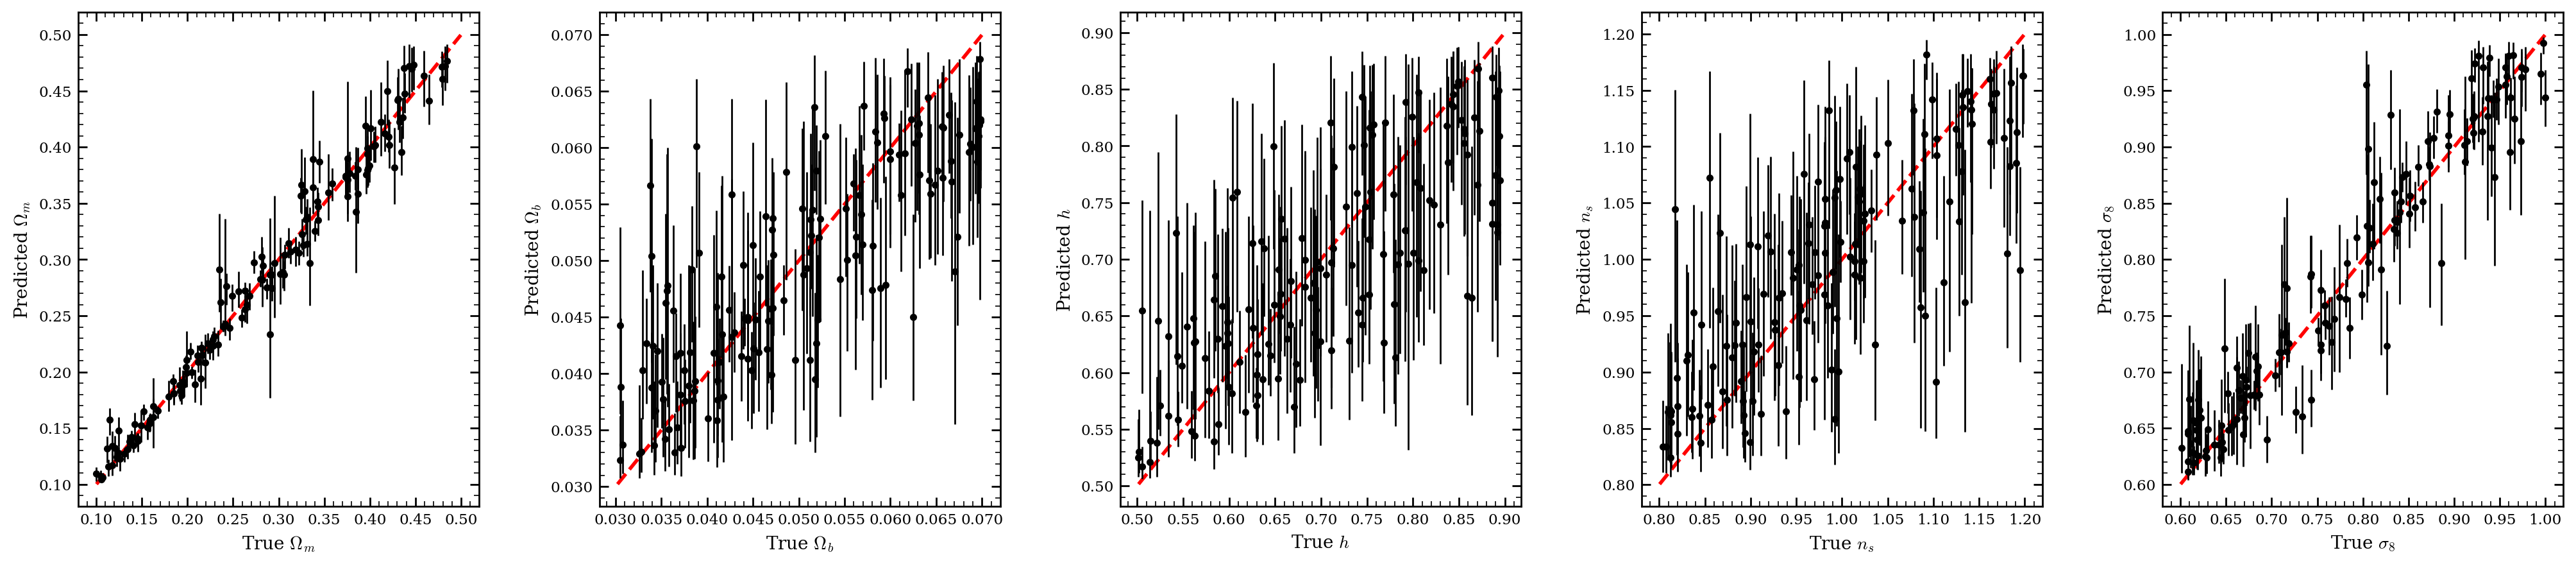

In [90]:
ss = 10

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')

In [91]:
# Load literature data
lit_path = join(wdir, 'literature', 'processed')

# SimBIG zPk024
filename = join(lit_path, 'simbig_pk.csv')
simpk = pd.read_csv(filename)
simpk.columns = names
simpk['Model'] = 'SimBIG zPk024'

# SimBIG zQk0
filename = join(lit_path, 'simbig_bk.csv')
simbk = pd.read_csv(filename)
simbk.columns = names
simbk['Model'] = 'SimBIG zQk0'

# print(simpk.shape, simbk.shape)
# simbk

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$')

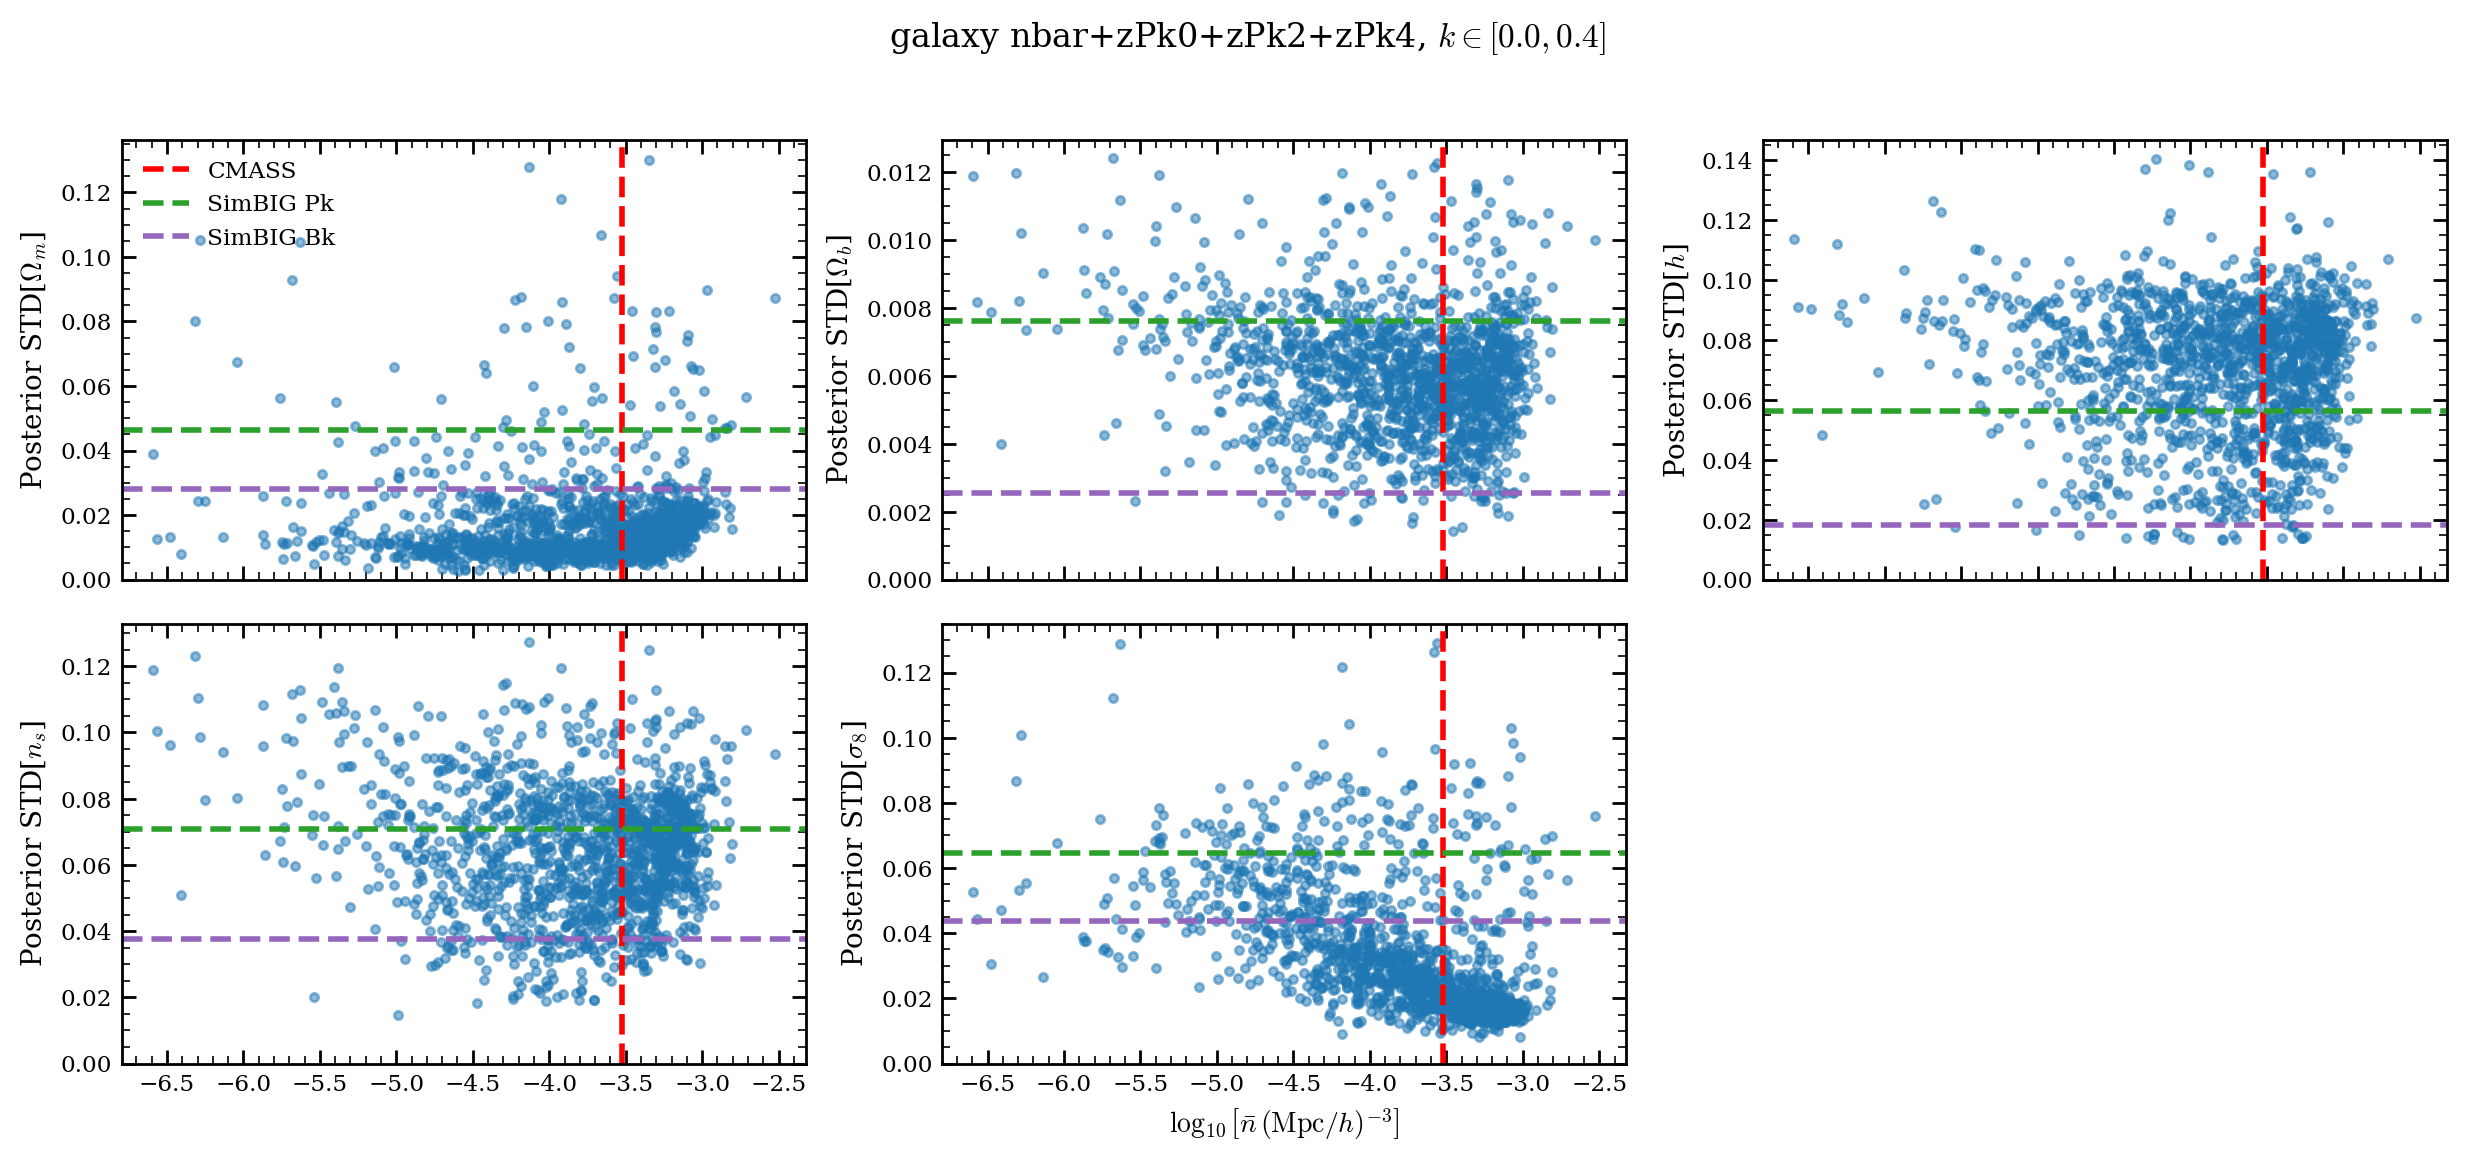

In [92]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    ax.plot(xtest[:, -1], samps.std(axis=0)[:, i], '.', alpha=0.5)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$')

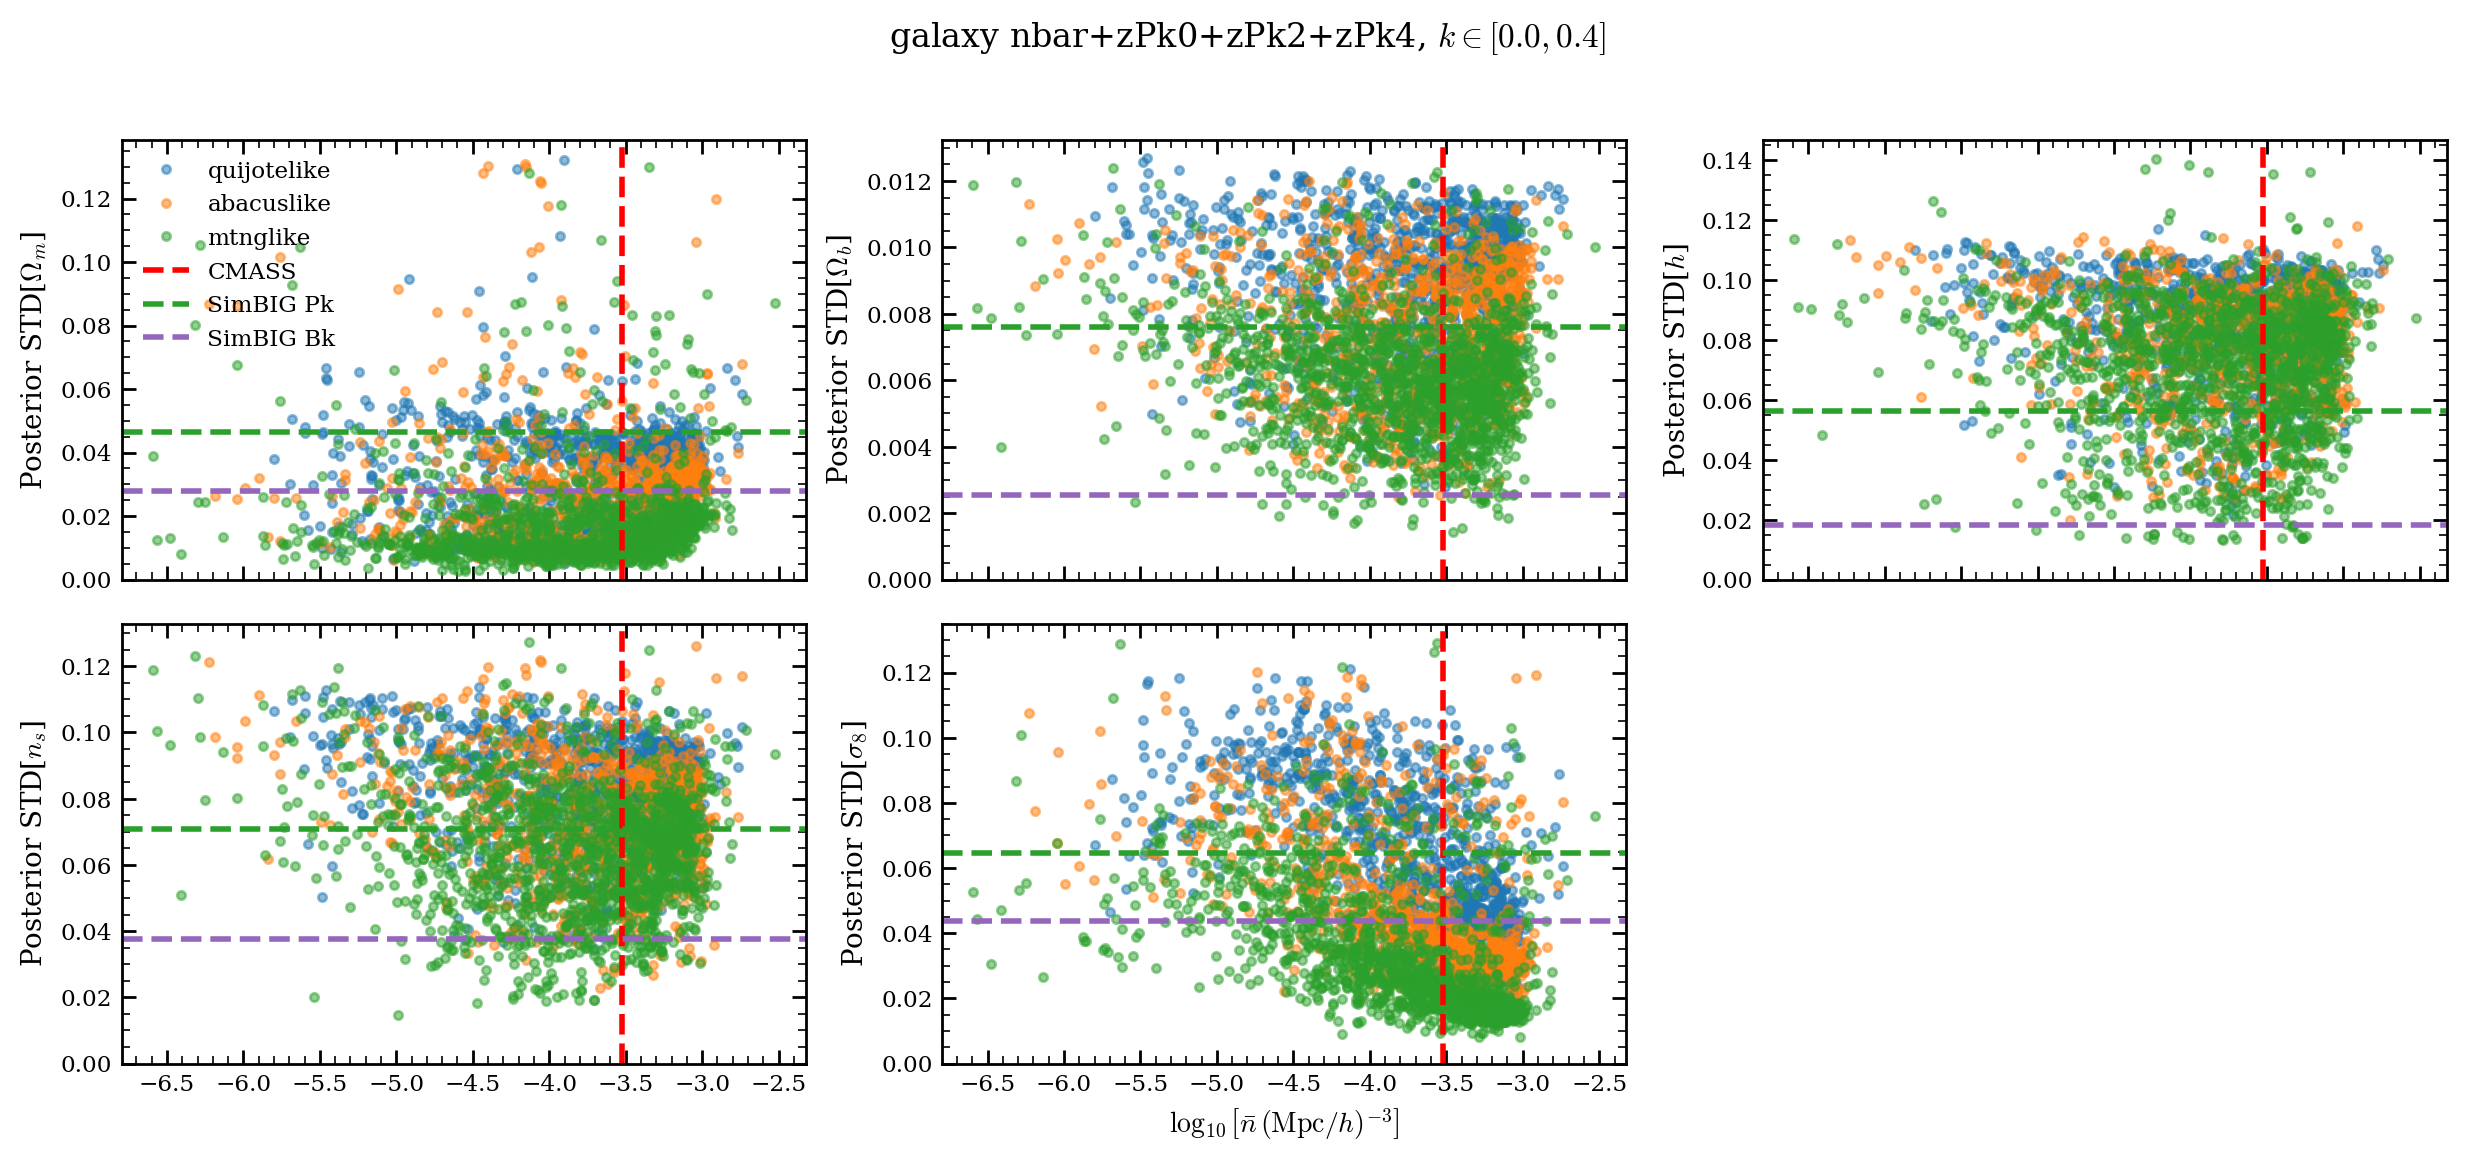

In [93]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    for j, n in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        ax.plot(xtest[:, -1], samps.std(axis=0)[:, i], '.', alpha=0.5, label=n)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$, $\\bar{n} \\sim \\bar{n}_{\\rm CMASS}$')

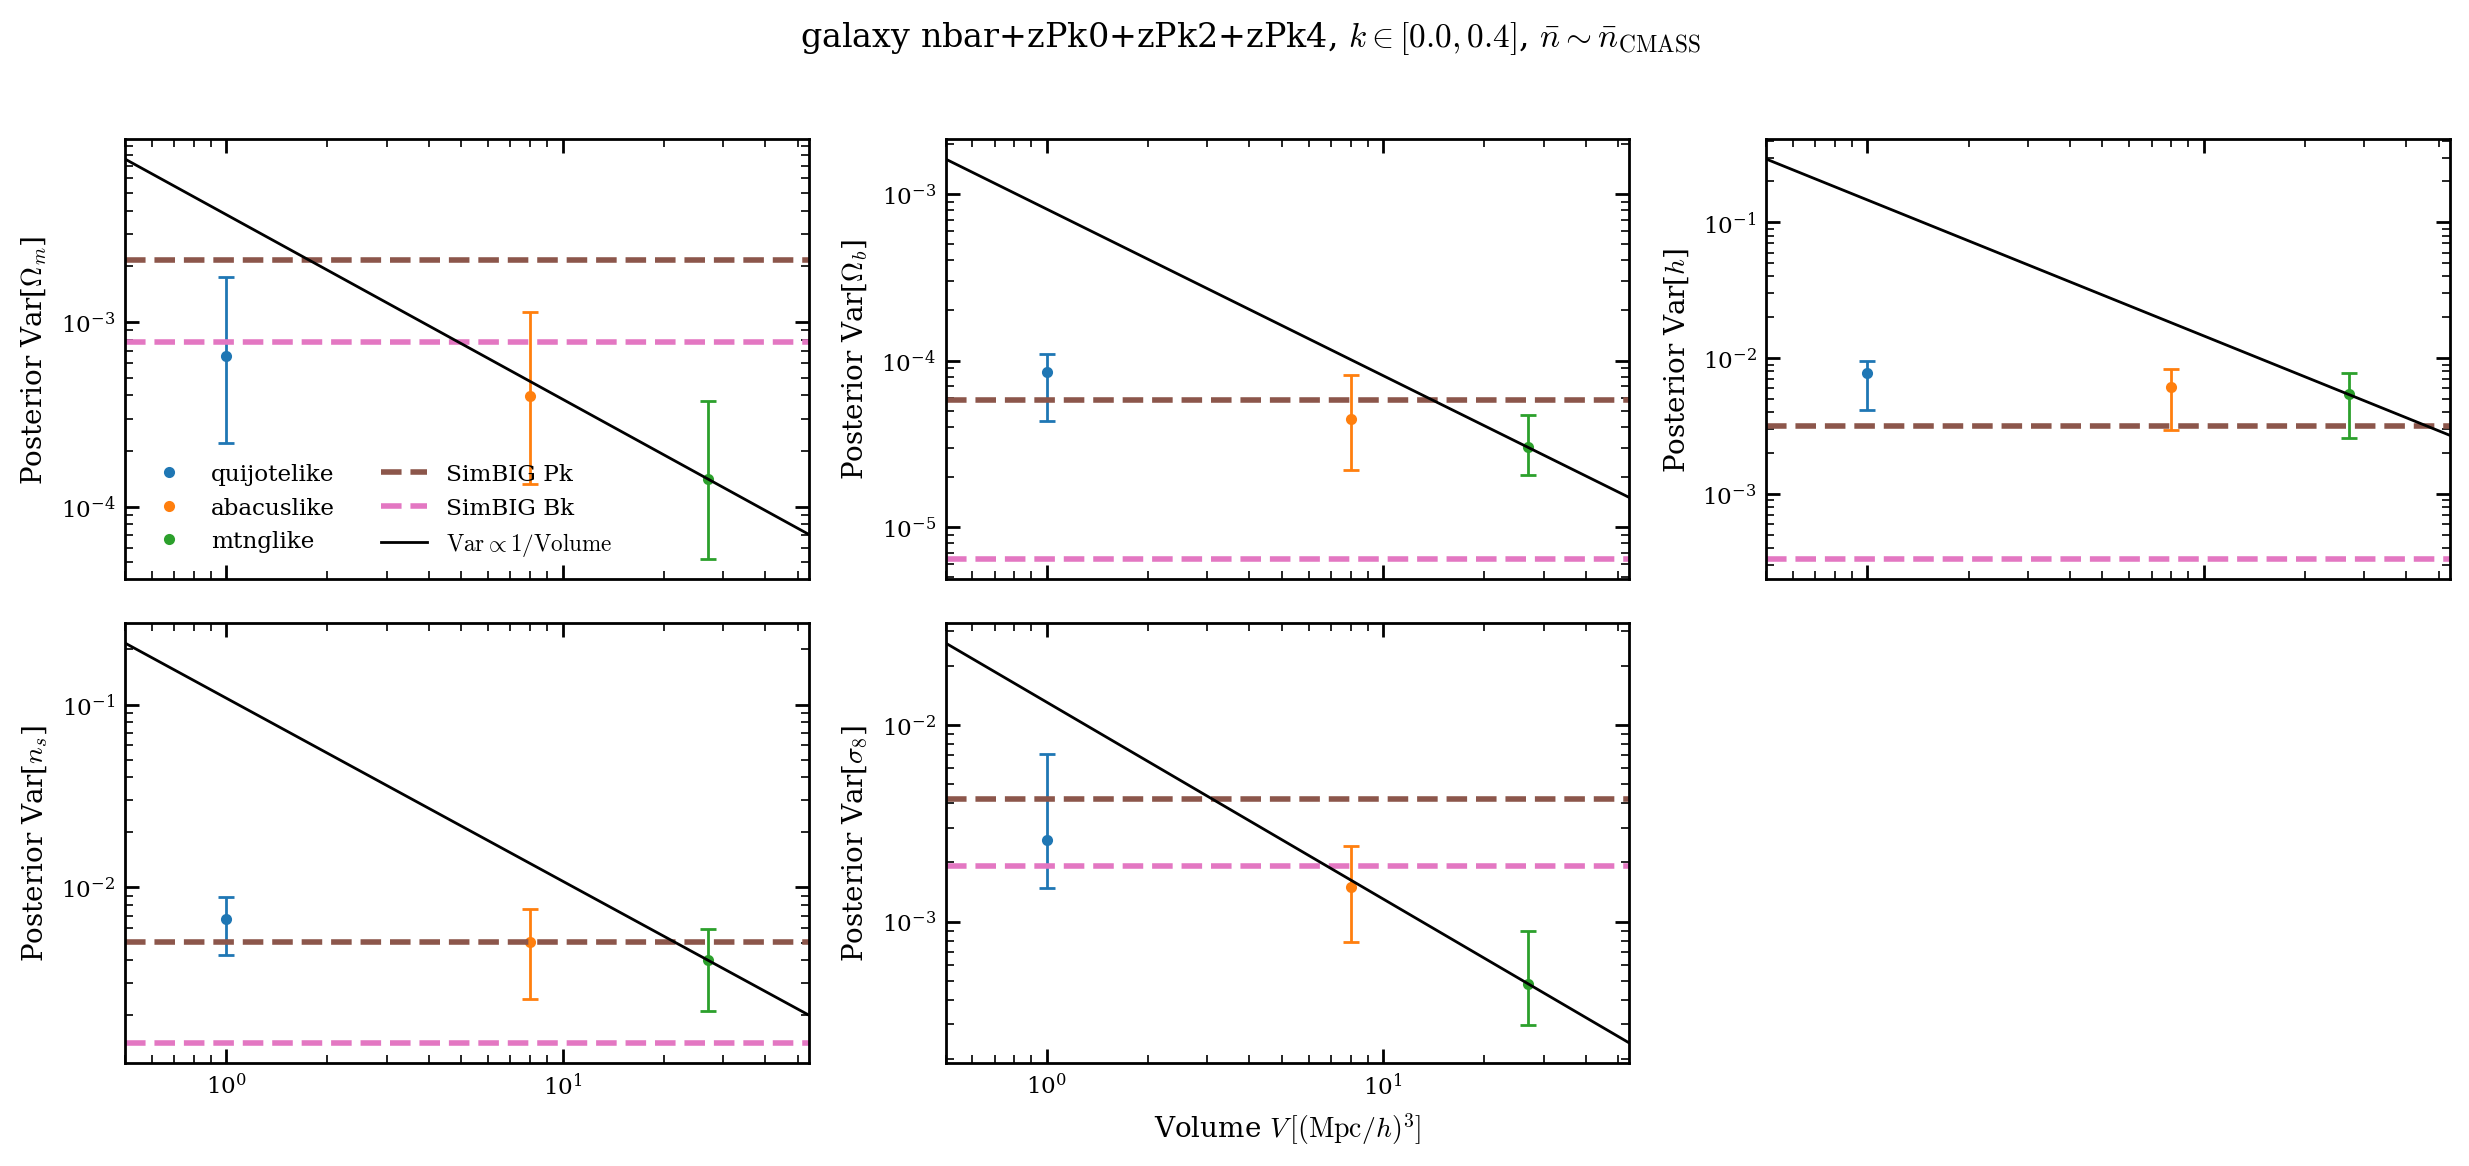

In [94]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.05
W, H = 3, len(names) // 3 + (len(names) % 3 > 0)

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(5 * W, 3 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue

    # Plot data for each suite
    for j, suite in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        mask = (xtest[:, -1] > nbar_CMASS -
                dnbar) & (xtest[:, -1] < nbar_CMASS + dnbar)
        p = np.percentile(samps[:, mask, i].var(axis=0), [16, 50, 84], axis=0)

        # Plot median and error bars
        ax.plot(vols[j], p[1], '.', label=suite, c=f'C{j}')
        yerr = np.array([[p[1] - p[0], p[2] - p[1]]]).T
        ax.errorbar(vols[j], p[1], yerr=yerr, fmt='none',
                    ecolor=f'C{j}', elinewidth=1, capsize=3, capthick=1)

    # Plot reference lines
    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Plot normalization curve
    norm_factor = p[1] / (1 / vols[j])
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, (1 / _v) * norm_factor, 'k-', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    if i == len(names) - 1:
        ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')
    if i == 0:
        ax.legend(ncol=2, loc='lower left')

# Set title
f.suptitle(f'{tracer} ' + '+'.join(summaries) +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$')

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$, $\\bar{n} \\sim \\bar{n}_{\\rm CMASS}$')

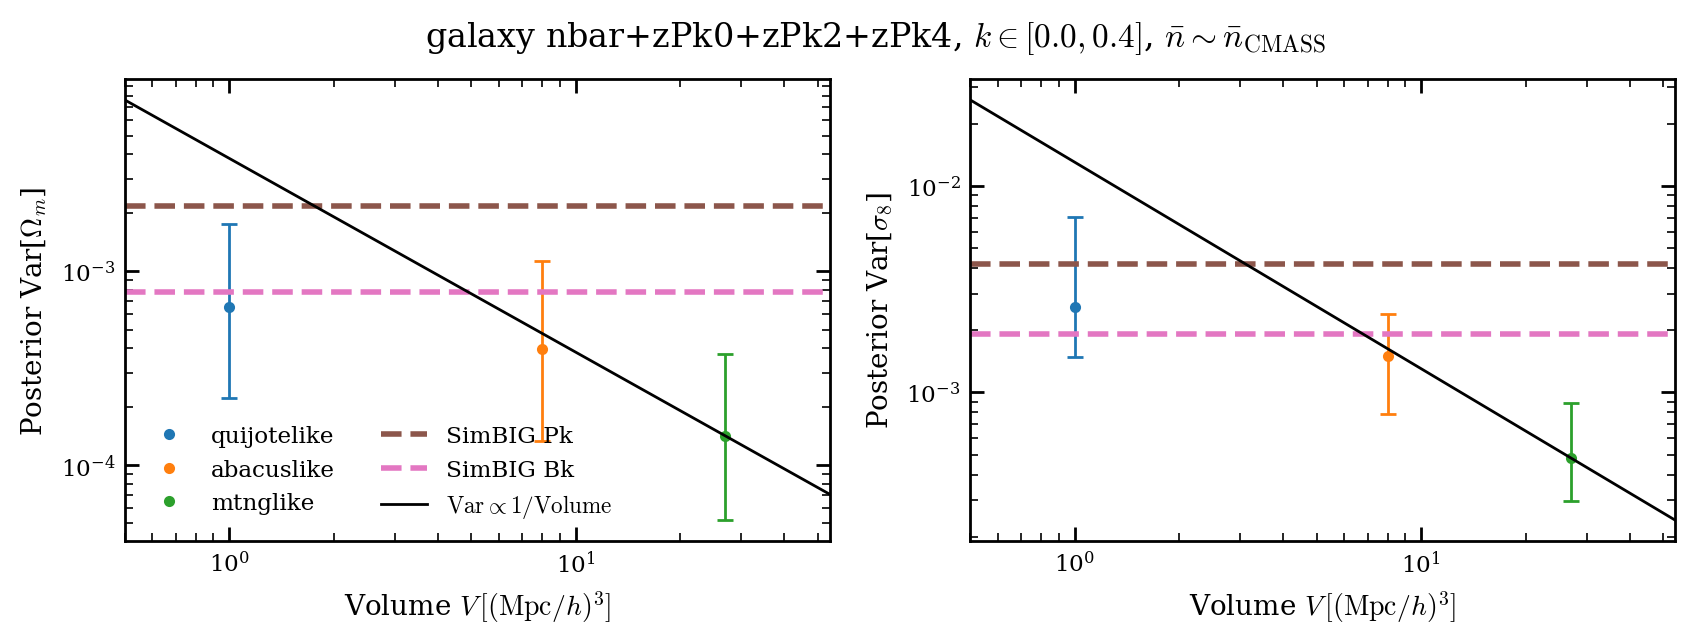

In [95]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

# Constants
nbar_CMASS = np.log10(3e-4)
dnbar = 0.05
# W, H = 3, len(names) // 3 + (len(names) % 3 > 0)
W, H = 2, 1

# Compute standard deviations
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

# Create subplots
f, axs = plt.subplots(H, W, figsize=(5 * W, 3 * H),
                      sharex=True, gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()

# Iterate over parameters
for k, i in enumerate([0, 4]):  # Only plot Omega_m and sigma_8
    ax = axs[k]
    if i >= len(names):
        ax.axis('off')
        continue

    # Plot data for each suite
    for j, suite in enumerate(suites):
        xtest = xtests[j]
        samps = sampss[j]
        mask = (xtest[:, -1] > nbar_CMASS -
                dnbar) & (xtest[:, -1] < nbar_CMASS + dnbar)
        p = np.percentile(samps[:, mask, i].var(axis=0), [16, 50, 84], axis=0)

        # Plot median and error bars
        ax.plot(vols[j], p[1], '.', label=suite, c=f'C{j}')
        yerr = np.array([[p[1] - p[0], p[2] - p[1]]]).T
        ax.errorbar(vols[j], p[1], yerr=yerr, fmt='none',
                    ecolor=f'C{j}', elinewidth=1, capsize=3, capthick=1)

    # Plot reference lines
    ax.axhline(sb_pkstd[i]**2, color='C5', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i]**2, color='C6', ls='--', label='SimBIG Bk')

    # Plot normalization curve
    norm_factor = p[1] / (1 / vols[j])
    _v = np.linspace(vols.min() / 2, vols.max() * 2, 100)
    ax.plot(_v, (1 / _v) * norm_factor, 'k-', lw=1,
            label=r'${\rm Var} \propto 1/{\rm Volume}$')

    # Set axis properties
    ax.loglog()
    ax.set_xlim(_v.min(), _v.max())
    ax.set_ylabel(f'Posterior Var[{names[i]}]')
    ax.set_xlabel(r'Volume $V\,[({\rm Mpc}/h)^3]$')
    if i == 0:
        ax.legend(ncol=2, loc='lower left')

# Set title
f.suptitle(f'{tracer} ' + '+'.join(summaries) +
           f', $k\\in[{kmin},{kmax}]$, ' + r'$\bar{n} \sim \bar{n}_{\rm CMASS}$')

100%|██████████| 20/20 [00:00<00:00, 1070.95it/s]


[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Log Probability')]

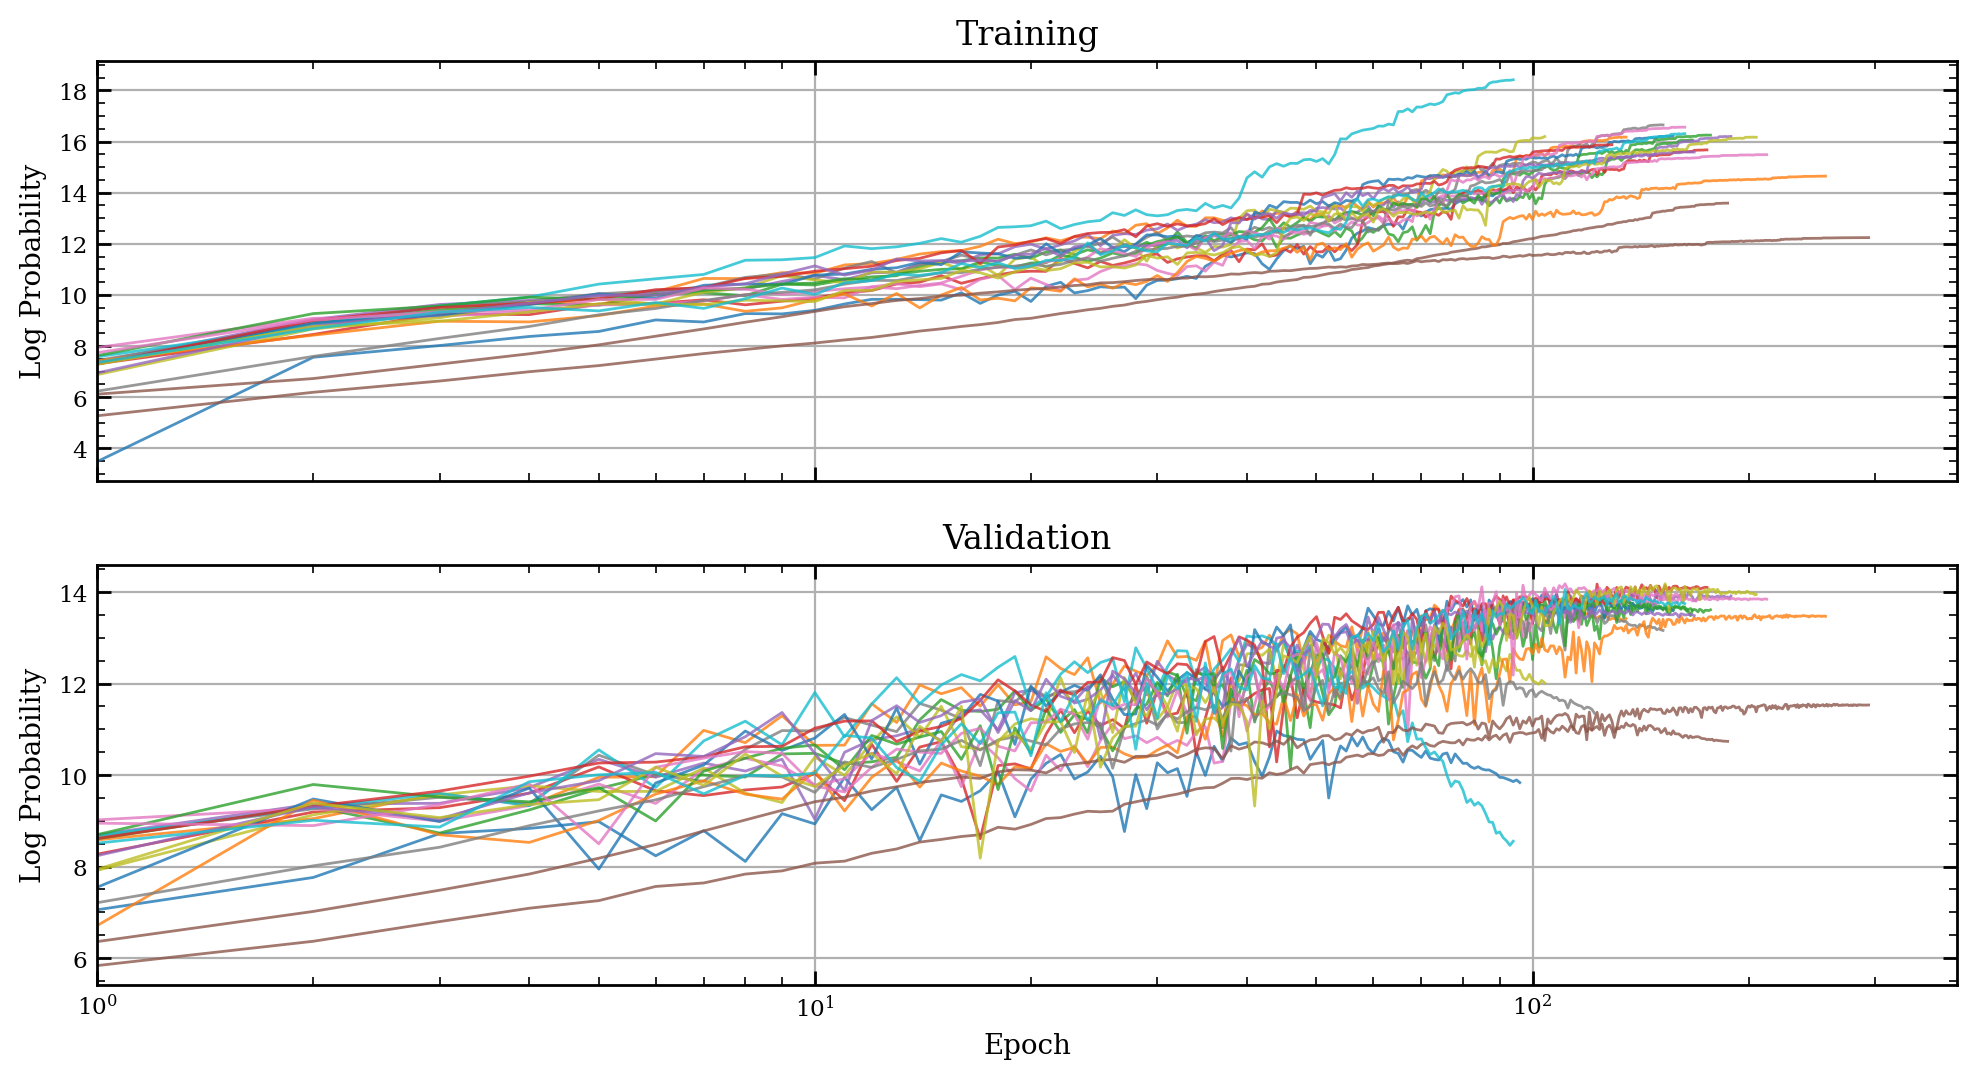

In [25]:
ss = 10

netpath = join(modelpath, 'nets')
netlist = os.listdir(netpath)

f, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for n in tqdm(netlist[::ss]):
    filepath = join(netpath, n, 'summary.json')
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        history = json.load(f)

    x_ = range(1, len(history[0]['training_log_probs'])+1)

    ax = axs[0]
    ax.plot(x_, history[0]['training_log_probs'], alpha=0.8, lw=1)

    ax = axs[1]
    ax.plot(x_, history[0]['validation_log_probs'], alpha=0.8, lw=1)

ax.semilogx()
ax.set_xlim(1)
# ax.set_ylim(-10, 20)

axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[0].grid()
axs[1].grid()

axs[0].set(ylabel='Log Probability')
axs[1].set(xlabel='Epoch', ylabel='Log Probability')